In [3]:
import numpy as np
from scipy.special import erf
import matplotlib.pyplot as plt

Semi-major axis a : 2.2405
Semi-minor axis b : 0.9695
Target area       : 5.0000
Recovered area    : 6.8244  (error: 1.82e+00)


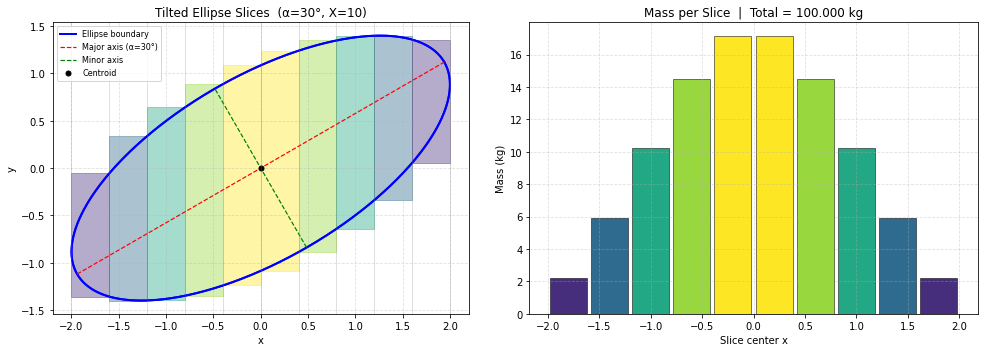

Slice  1 | x_center: -1.800 | mass: 2.2295 kg
Slice  2 | x_center: -1.400 | mass: 5.9022 kg
Slice  3 | x_center: -1.000 | mass: 10.2588 kg
Slice  4 | x_center: -0.600 | mass: 14.4787 kg
Slice  5 | x_center: -0.200 | mass: 17.1308 kg
Slice  6 | x_center: +0.200 | mass: 17.1308 kg
Slice  7 | x_center: +0.600 | mass: 14.4787 kg
Slice  8 | x_center: +1.000 | mass: 10.2588 kg
Slice  9 | x_center: +1.400 | mass: 5.9022 kg
Slice 10 | x_center: +1.800 | mass: 2.2295 kg

Sum of slice masses: 100.0000 kg


In [ ]:
import numpy as np
from scipy.special import erf
from scipy import integrate, optimize
import matplotlib.pyplot as plt


def discretize_tilted_ellipse_mass(width, A, D, angle_deg, bulk_property, X,
                                   plot=True):
    """
    Discretize a Gaussian mass distribution over a TILTED ellipse into X vertical slices.

    The Gaussian is defined in the ellipse's local frame (along semi-axes a, b).
    The 2-sigma contour of the Gaussian coincides with the ellipse boundary.

    Parameters:
        width      : total x-extent of the tilted ellipse
        A          : cross-sectional area of the ellipse
        D          : effective depth = half-height at x=centroid (x=0)
        angle_deg  : angle of major axis from x-axis (degrees)
        bulk_property : bulk property to distribute (e.g., mass, number)
        X          : number of vertical slices

    Returns:
        slice_centers : x positions of slice centers
        slice_masses  : integrated mass in each slice
    """
    alpha = np.radians(angle_deg)
    ca, sa = np.cos(alpha), np.sin(alpha)

    # -------------------------------------------------------------------------
    # Step 1: Recover semi-axes a, b from (width, D, alpha)
    # -------------------------------------------------------------------------
    def equations(params):
        a_, b_ = params
        eq1 = (a_ * ca)**2 + (b_ * sa)**2 - (width / 2)**2
        eq2 = (a_ * sa)**2 + (b_ * ca)**2 - D**2
        return [eq1, eq2]

    a0 = width / 2
    b0 = A / (np.pi * a0)
    a_sol, b_sol = optimize.fsolve(equations, [a0, b0])

    A_check = np.pi * a_sol * b_sol
    print(f"Semi-major axis a : {a_sol:.4f}")
    print(f"Semi-minor axis b : {b_sol:.4f}")
    print(f"Target area       : {A:.4f}")
    print(f"Recovered area    : {A_check:.4f}  (error: {abs(A_check-A):.2e})")

    # Gaussian sigmas in the ellipse's local frame (2-sigma = semi-axis length)
    sigma_a = a_sol / 2
    sigma_b = b_sol / 2

    # -------------------------------------------------------------------------
    # Step 2: x-extent of the tilted ellipse
    # -------------------------------------------------------------------------
    x_max = width / 2   # = sqrt((a*ca)^2 + (b*sa)^2), consistent by construction
    x_min = -x_max

    # -------------------------------------------------------------------------
    # Step 3: y-limits at a given x by intersecting vertical line with tilted ellipse
    #
    # Substitute rotated coords u = x*ca + y*sa, v = -x*sa + y*ca into
    # (u/a)^2 + (v/b)^2 = 1  =>  quadratic in y:
    #   (sa^2/a^2 + ca^2/b^2)*y^2
    #   + 2*x*(ca*sa/a^2 - ca*sa/b^2)*y
    #   + x^2*(ca^2/a^2 + sa^2/b^2) - 1 = 0
    # -------------------------------------------------------------------------
    def y_limits(x):
        A_q = sa**2 / a_sol**2 + ca**2 / b_sol**2
        B_q = 2 * x * ca * sa * (1 / a_sol**2 - 1 / b_sol**2)
        C_q = x**2 * (ca**2 / a_sol**2 + sa**2 / b_sol**2) - 1
        disc = B_q**2 - 4 * A_q * C_q
        if disc < 0:
            return None, None   # x is outside the ellipse
        sqrt_disc = np.sqrt(disc)
        y1 = (-B_q - sqrt_disc) / (2 * A_q)
        y2 = (-B_q + sqrt_disc) / (2 * A_q)
        return min(y1, y2), max(y1, y2)

    # -------------------------------------------------------------------------
    # Step 4: 2D Gaussian in the ellipse's LOCAL (rotated) frame
    #
    # u =  x*cos(a) + y*sin(a)   (along major axis)
    # v = -x*sin(a) + y*cos(a)   (along minor axis)
    # G(x,y) = exp(-u^2 / 2*sigma_a^2) * exp(-v^2 / 2*sigma_b^2)
    # -------------------------------------------------------------------------
    def gaussian_2d(x, y):
        u =  x * ca + y * sa
        v = -x * sa + y * ca
        return (np.exp(-u**2 / (2 * sigma_a**2)) *
                np.exp(-v**2 / (2 * sigma_b**2)))

    # -------------------------------------------------------------------------
    # Step 5: Normalization — integrate Gaussian strictly inside tilted ellipse
    # -------------------------------------------------------------------------
    def norm_integrand(y, x):
        return gaussian_2d(x, y)

    def y_lo_fn(x):
        lo, _ = y_limits(x)
        return lo if lo is not None else 0.0

    def y_hi_fn(x):
        _, hi = y_limits(x)
        return hi if hi is not None else 0.0

    norm_integral, _ = integrate.dblquad(
        norm_integrand,
        x_min, x_max,
        y_lo_fn, y_hi_fn
    )
    scale = bulk_property / norm_integral

    # -------------------------------------------------------------------------
    # Step 6: Integrate each vertical slice
    #
    # For each x, the y-integral of the Gaussian can use erf IF the Gaussian
    # were axis-aligned in y. But since G is in the rotated frame, the
    # y-dependence at fixed x mixes u and v — so we keep full numerical quad.
    # -------------------------------------------------------------------------
    dx = width / X
    slice_centers = np.linspace(x_min + dx / 2, x_max - dx / 2, X)
    slice_properties = np.zeros(X)

    for i, x_c in enumerate(slice_centers):
        x_lo = np.clip(x_c - dx / 2, x_min, x_max)
        x_hi = np.clip(x_c + dx / 2, x_min, x_max)

        def strip_integrand(y, x):
            return gaussian_2d(x, y)

        def y_lo_strip(x):
            lo, _ = y_limits(x)
            return lo if lo is not None else 0.0

        def y_hi_strip(x):
            _, hi = y_limits(x)
            return hi if hi is not None else 0.0

        mass_strip, _ = integrate.dblquad(
            strip_integrand,
            x_lo, x_hi,
            y_lo_strip, y_hi_strip
        )
        slice_properties[i] = scale * mass_strip

    # -------------------------------------------------------------------------
    # Step 7: Plot
    # -------------------------------------------------------------------------
    if plot:
        t = np.linspace(0, 2 * np.pi, 500)
        x_ell = a_sol * np.cos(t) * ca - b_sol * np.sin(t) * sa
        y_ell = a_sol * np.cos(t) * sa + b_sol * np.sin(t) * ca

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # -- Left: ellipse geometry with slices --
        ax = axes[0]
        ax.plot(x_ell, y_ell, 'b-', linewidth=2, label='Ellipse boundary')

        # Slice shading
        cmap = plt.cm.viridis
        m_norm = slice_properties / slice_properties.max()
        for i, (x_c, m) in enumerate(zip(slice_centers, m_norm)):
            x_lo = x_c - dx / 2
            x_hi = x_c + dx / 2
            # Sample y limits across this strip
            xs = np.linspace(x_lo, x_hi, 20)
            y_los, y_his = [], []
            for xv in xs:
                lo, hi = y_limits(xv)
                if lo is not None:
                    y_los.append(lo); y_his.append(hi)
            if y_los:
                ax.fill_betweenx(
                    np.linspace(min(y_los), max(y_his), 100),
                    x_lo, x_hi,
                    alpha=0.4, color=cmap(m_norm[i])
                )

        ax.plot(x_ell, y_ell, 'b-', linewidth=2)  # redraw on top
        # Major/minor axes
        ax.plot([-a_sol*ca, a_sol*ca], [-a_sol*sa, a_sol*sa],
                'r--', lw=1.2, label=f'Major axis (α={angle_deg}°)')
        ax.plot([b_sol*sa, -b_sol*sa], [-b_sol*ca, b_sol*ca],
                'g--', lw=1.2, label='Minor axis')
        ax.plot(0, 0, 'ko', markersize=5, label='Centroid')

        # Vertical slice lines
        for x_c in slice_centers:
            ax.axvline(x_c - dx/2, color='gray', lw=0.5, alpha=0.5)
        ax.axvline(slice_centers[-1] + dx/2, color='gray', lw=0.5, alpha=0.5)

        ax.set_aspect('equal')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=8)
        ax.set_title(f'Tilted Ellipse Slices  (α={angle_deg}°, X={X})')
        ax.set_xlabel('x'); ax.set_ylabel('y')

        # -- Right: mass per slice bar chart --
        ax2 = axes[1]
        colors = [cmap(m) for m in m_norm]
        ax2.bar(slice_centers, slice_properties, width=dx*0.9, color=colors, edgecolor='k', linewidth=0.5)
        ax2.set_xlabel('Slice center x')
        ax2.set_ylabel('Mass (kg)')
        ax2.set_title(f'Mass per Slice  |  Total = {slice_properties.sum():.3f} kg')
        ax2.grid(True, linestyle='--', alpha=0.4)

        plt.tight_layout()
        plt.show()

    return slice_centers, slice_properties

# --- Example usage ---
centers, masses = discretize_tilted_ellipse_mass(
    width=4.0,
    A=5.0,
    D=1.4,
    angle_deg=30,
    total_mass=100.0,
    X=10,
    plot=True
)

for i, (c, m) in enumerate(zip(centers, masses)):
    print(f"Slice {i+1:2d} | x_center: {c:+.3f} | mass: {m:.4f} kg")
print(f"\nSum of slice masses: {masses.sum():.4f} kg")